## 定义模型

In [1]:
import os
from langchain_community.chat_models import ChatTongyi
llm = ChatTongyi(
    model="qwen3-235b-a22b-instruct-2507",  # 推荐使用 qwen-max 或 qwen-plus 以获得更好的指令遵循能力
    dashscope_api_key=os.getenv("DASHSCOPE_API_KEY"),
    temperature=0.0    # 结构化输出建议将温度设为 0
)

## 定义任务格式

In [2]:
from typing import Annotated, List
from pydantic import BaseModel, Field

# Schema for structured output to use in planning
class Section(BaseModel):
    name: str = Field(
        description="章节名称",
    )
    description: str = Field(
        description="章节概要与关键信息",
    )

class Sections(BaseModel):
    sections: List[Section] = Field(
        description="文章章节列表",
    )

# Augment the LLM with schema for structured output
planner = llm.with_structured_output(Sections)

## 定义节点

In [3]:
import operator
from typing import TypedDict, Annotated
from langgraph.types import Send
from langchain.messages import HumanMessage, SystemMessage

# Graph state
class State(TypedDict):
    topic: str  # Report topic
    sections: list[Section]  # List of report sections
    completed_sections: Annotated[
        list, operator.add
    ]  # All workers write to this key in parallel
    final_report: str  # Final report


# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


# Nodes
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="生成一个写作报告的章节"),
            HumanMessage(content=f"写作主题为 {state['topic']}"),
        ]
    )

    return {"sections": report_sections.sections}


def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="根据给定的章节和描述，生成一个段落，用markdownn格式输出，不超过300字。"
            ),
            HumanMessage(
                content=f"章节 {state['section'].name} ，描述: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}


def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}


# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]

## 构建图

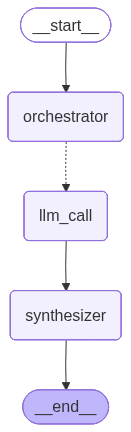

In [4]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, MessagesState, START, END

# Build workflow
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))


In [5]:
# Invoke
state = orchestrator_worker.invoke({"topic": "人性的善与恶"})

from IPython.display import Markdown
Markdown(state["final_report"])

# 引言：善与恶的永恒命题

善与恶，作为人类道德判断的核心范畴，自文明诞生之初便深深植根于思想的土壤之中。何为善？何为恶？这一看似简单的问题，实则牵涉伦理、宗教、哲学乃至心理学的深层探讨。在古希腊，苏格拉底主张“知识即美德”，认为作恶源于无知；而柏拉图则通过灵魂三分说揭示人性中理性与欲望的冲突。东方哲思中，孟子倡“性善论”，荀子主“性恶论”，展开了对人性本源的深刻辩证。这些古老对话不仅奠定了善恶命题的思想基石，也映照出人类对自我认知的不懈追寻。时至今日，在科技迅猛发展、价值多元碰撞的现实中，善恶的边界愈发模糊——从人工智能的伦理困境到社会正义的争议，这一古老命题仍不断叩问着我们的良知与选择。理解善与恶，不仅是哲学的思辨，更是面对现实生活的必要智慧。

---

# 善的本质：利他与共情

人性中的“善”常体现为同情心、合作行为与道德责任感，这些品质不仅是社会和谐的基石，也在心理学与进化论中找到深层解释。心理学研究表明，共情能力是利他行为的重要驱动力——当个体能感知他人痛苦时，更可能伸出援手。镜像神经元系统的发现进一步揭示了共情的神经基础，说明人类天生具备理解他人情感的生理机制。从进化论视角看，利他行为虽看似违背“适者生存”原则，但在群体选择理论中却具有适应性价值：合作增强群体凝聚力，提高整体生存几率。早期人类依赖协作获取资源、抵御外敌，促使利他基因得以传承。此外，道德责任感作为内在规范，通过社会化过程内化，使个体在无外部监督时仍能行善。综上，善并非纯粹文化建构，而是根植于人类心理与生物演化的历史长河之中，是共情与合作在自然选择中淬炼出的光辉结晶。

---

# 恶的根源：自私与权力欲

“恶”并非凭空而生，其深层根植于人性中的自私与对权力的渴望。个体在欲望驱使下，贪婪攫取资源，嫉妒他人成就，进而滋生怨恨与攻击性。当这些情绪无法被理性与道德约束时，便可能外化为伤害行为。尤其在群体中，个体责任被稀释，集体暴力往往以“正义”之名蔓延，如舆论猎巫、种族迫害等现象，皆是私欲与权力操控的产物。权力不仅吸引自私者争夺，更在获取后腐蚀持有者，使其为维持控制不择手段。从独裁统治到职场霸凌，权力欲不断催化压迫与不公。因此，“恶”既是内在心理失衡的结果，也是社会结构失序的映照。唯有正视人性弱点，建立制衡机制与共情伦理，方能在个体与集体层面遏制恶的滋长。

---

# 善恶的边界：情境与选择

善与恶并非固定不变的标签，而是在特定情境下由环境、文化与个人抉择共同塑造的动态过程。斯坦福监狱实验揭示了普通人如何在权力结构与角色扮演中迅速滑向压迫或顺从的极端——原本心理健康的大学生在模拟监狱环境中，短短数日内便表现出虐待或崩溃的行为。这一实验表明，情境的力量足以重塑道德判断，挑战“邪恶源于本性”的传统观念。不同文化对同一行为的善恶界定也迥异，如集体主义与个人主义社会对“忠诚”与“反抗”的评价截然不同。最终，个体在压力、规范与信念之间的抉择，决定了其跨越边界的走向。善恶之间没有绝对的鸿沟，而是充满张力的灰色地带。理解这一点，不是为了消解道德责任，而是提醒我们警惕环境对人心的无形塑造，并在关键时刻保持清醒的自主选择。

---

## 超越二元对立：复杂的人性

人性从非简单的黑白图谱，多数灵魂栖居于善恶交织的幽微灰色地带。我们既可能在危难中伸出援手，亦可能因私欲而伤害他人；英雄会犯错，恶人或有温情瞬间。这种复杂性拒绝被轻易归类——它如光谱般流动、矛盾且深刻。正因如此，理解与反思才成为必要：唯有放下非此即彼的评判，以同理心审视行为背后的动机与困境，我们才能真正触碰人性的真实质地，在混沌中寻求共情与成长的可能。

---

# 结语：向善之路的可能

人性之中，善与恶始终并存，但向善并非命运的偶然，而是选择的结果。教育是培育良知的第一步，它不仅传授知识，更应引导人理解共情、正义与责任。通过制度建设，社会可为善行提供保障，对恶行形成制约，使公平与秩序成为现实可能。然而，制度与教育之外，个体的自我觉察同样不可或缺——唯有在日常生活中不断反思自身动机与行为，人才能在诱惑与冷漠面前坚守内心的光明。向善之路并不平坦，却值得每个人坚定前行。我们无法消除所有黑暗，但可以通过点滴努力，让善的光芒更加明亮。愿每一个人都能成为善的践行者与传递者，在彼此照亮中，共建一个更温暖、更有希望的世界。